# 04 Pseudoexperiment and fit
Poisson pseudo-data, normalization fit and contour.

In [1]:
from pathlib import Path
import os, sys
PROJECT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT / "outputs" / "mplconfig"))
(PROJECT / "outputs").mkdir(exist_ok=True)
(PROJECT / "outputs" / "mplconfig").mkdir(exist_ok=True)
sys.path.insert(0, str(PROJECT / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from solar_neutrino.spectra import load_b8_spectrum, normalize_spectrum, interpolate_spectrum
from solar_neutrino.oscillations import OscillationParameters, compute_survival_probability_grid
from solar_neutrino.cross_sections import nu_e_elastic_toy
from solar_neutrino.detector import efficiency, expected_events
from solar_neutrino.pseudoexperiment import generate_poisson_data
from solar_neutrino.fit import poisson_chi2, scan_normalization, scan_two_parameters, find_best_fit, delta_chi2
from solar_neutrino.plotting import plot_expected_vs_observed, plot_chi2_scan, plot_contour

## Expected spectrum

In [2]:
E, shape = load_b8_spectrum(PROJECT / "data" / "b8_spectrum.csv")
shape = normalize_spectrum(E, shape); interp = interpolate_spectrum(E, shape)
E_bins = np.linspace(3.0, 15.0, 13); E_centers = 0.5 * (E_bins[:-1] + E_bins[1:])
flux_centers = interp(E_centers); pee_centers = compute_survival_probability_grid(E_centers, OscillationParameters())
xs_eff = nu_e_elastic_toy(E_centers) * efficiency(E_centers); exposure = 2200.0
expected = expected_events(E_bins, flux_centers, pee_centers, xs_eff, exposure=exposure)

## Poisson pseudo-data

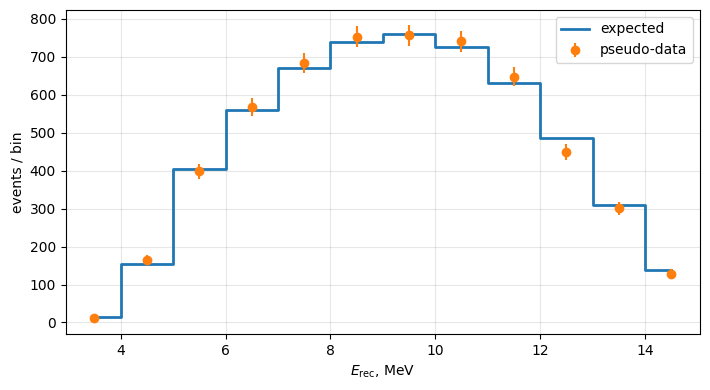

In [3]:
observed = generate_poisson_data(expected, seed=12345)
fig, ax = plt.subplots(figsize=(7.2, 4.0))
plot_expected_vs_observed(E_centers, expected, observed, ax=ax)
fig.tight_layout(); fig.savefig(PROJECT / "outputs" / "expected_vs_observed_notebook.png", dpi=160); plt.show()

## Fit normalization

In [4]:
norm_grid = np.linspace(0.5, 1.5, 301)
scan = scan_normalization(observed, expected, norm_grid); best = find_best_fit(scan); delta = delta_chi2(scan)
inside = norm_grid[delta <= 1.0]; ci = (inside.min(), inside.max()) if inside.size else (np.nan, np.nan)
best, ci

({'index': (np.int64(151),),
  'chi2': 6.833866457420979,
  'parameters': (1.0033333333333334,)},
 (np.float64(0.99), np.float64(1.0133333333333334)))

## Chi-square scan

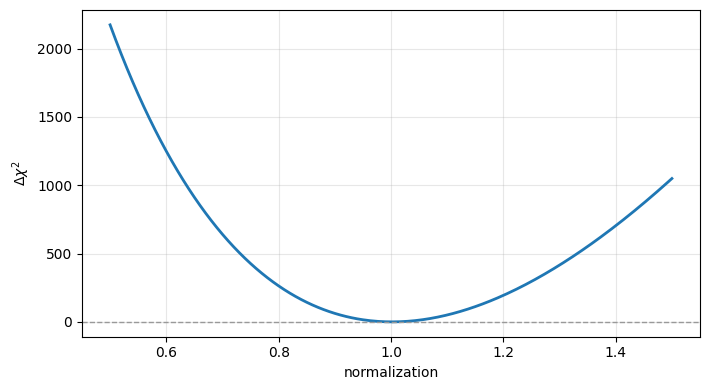

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
plot_chi2_scan(norm_grid, scan["chi2"], ax=ax); ax.set_xlabel("normalization")
fig.tight_layout(); fig.savefig(PROJECT / "outputs" / "chi2_scan_notebook.png", dpi=160); plt.show()

## Effective Pee and 2D contour

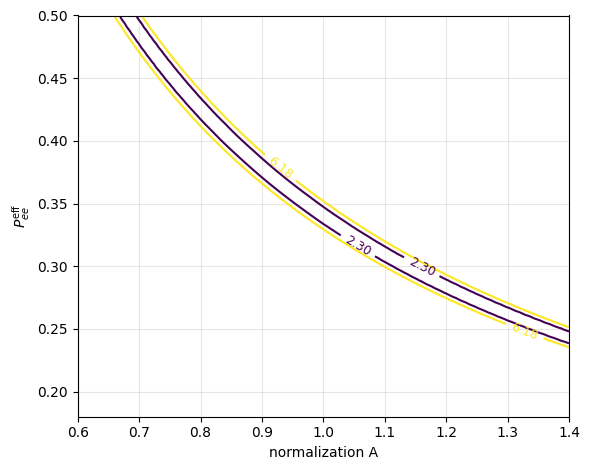

{'best_fit_effective_Pee': 0.3411371237458194}

In [6]:
P_grid = np.linspace(0.10, 0.80, 300)
base_no_pee = expected_events(E_bins, flux_centers, np.ones_like(E_centers), xs_eff, exposure=exposure)
chi2_P = np.array([poisson_chi2(observed, P * base_no_pee) for P in P_grid])
best_P = P_grid[np.argmin(chi2_P)]
A_grid = np.linspace(0.6, 1.4, 101); P2_grid = np.linspace(0.18, 0.50, 101)
def model(A, P): return A * P * base_no_pee
scan2 = scan_two_parameters(observed, model, A_grid, P2_grid)
fig, ax = plt.subplots(figsize=(6.0, 4.8))
plot_contour(A_grid, P2_grid, delta_chi2(scan2), ax=ax, levels=(2.30, 6.18))
ax.set_xlabel("normalization A"); ax.set_ylabel(r"$P_{ee}^{\rm eff}$")
fig.tight_layout(); fig.savefig(PROJECT / "outputs" / "contour_scan_notebook.png", dpi=160); plt.show()
{"best_fit_effective_Pee": float(best_P)}